<a href="https://colab.research.google.com/github/nataliatheodorou123/---/blob/main/%CE%95%CF%81%CE%B3%CE%B1%CF%83%CE%AF%CE%B1(Upvotes).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn import metrics

from sklearn.linear_model import LinearRegression

%matplotlib inline

In [2]:
train_df=pd.read_csv("/content/train_NIR5Yl1.csv.zip")
test_df=pd.read_csv("/content/test_8i3B3FC.csv.zip")

In [3]:
train_df.copy()

,ID,Tag,Reputation,Answers,Username,Views,Upvotes
0,52664,a,3942.0,2.0,155623,7855.0,42.0
1,327662,a,26046.0,12.0,21781,55801.0,1175.0
2,468453,c,1358.0,4.0,56177,8067.0,60.0
3,96996,a,264.0,3.0,168793,27064.0,9.0
4,131465,c,4271.0,4.0,112223,13986.0,83.0
...,...,...,...,...,...,...,...
330040,339800,c,36.0,2.0,84919,1063.0,0.0
330041,253800,c,1649.0,2.0,76730,23319.0,73.0
330042,210756,c,6178.0,2.0,91701,2453.0,15.0
330043,56089,j,89.0,2.0,80245,2107.0,3.0


In [4]:
train_df.head()

,ID,Tag,Reputation,Answers,Username,Views,Upvotes
0,52664,a,3942.0,2.0,155623,7855.0,42.0
1,327662,a,26046.0,12.0,21781,55801.0,1175.0
2,468453,c,1358.0,4.0,56177,8067.0,60.0
3,96996,a,264.0,3.0,168793,27064.0,9.0
4,131465,c,4271.0,4.0,112223,13986.0,83.0


In [5]:
train_df.shape,test_df.shape

((330045, 7), (141448, 6))

In [6]:
test_df.head()

,ID,Tag,Reputation,Answers,Username,Views
0,366953,a,5645.0,3.0,50652,33200.0
1,71864,c,24511.0,6.0,37685,2730.0
2,141692,i,927.0,1.0,135293,21167.0
3,316833,i,21.0,6.0,166998,18528.0
4,440445,i,4475.0,10.0,53504,57240.0


In [7]:
train_df.drop(['ID','Username'],axis=1,inplace=True)

In [8]:
X=train_df.drop("Upvotes",axis=1)
y=train_df['Upvotes']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=44,shuffle=True)

In [10]:
model = LinearRegression()

In [12]:
X_encoded = pd.get_dummies(X, columns=['Tag'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=44, shuffle=True)
model.fit(X_train, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test)

In [14]:
MAE= metrics.mean_absolute_error(y_test, y_pred)
MSE=metrics.mean_squared_error(y_test, y_pred)
RMSE= np.sqrt(MSE)

In [15]:
print(f'MAE: {MAE}')
print(f'MSE: {MSE}')
print(f'RMSE: {RMSE}')

MAE: 585.5421989894453
MSE: 4535929.94199624
RMSE: 2129.772274680145


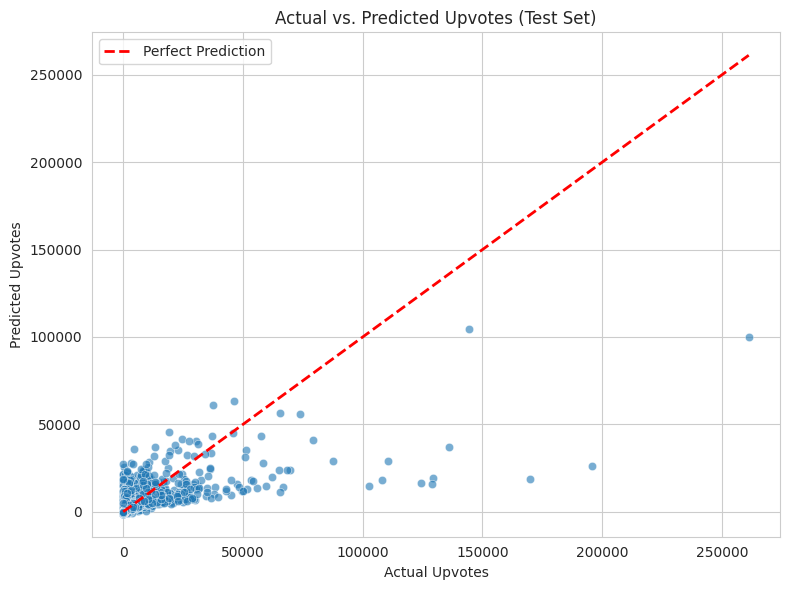

Visualization of model predictions and actual vs. predicted upvotes completed.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Create a scatter plot of Actual vs. Predicted Upvotes
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted Upvotes (Test Set)')
plt.xlabel('Actual Upvotes')
plt.ylabel('Predicted Upvotes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Visualization of model predictions and actual vs. predicted upvotes completed.")